### Penjelasan Variabel Dataset

Berdasarkan analisis pada *notebook* `Pertemuan 4.ipynb` dan dataset `Loan Dataset.csv`, berikut adalah penjelasan untuk setiap variabel yang dipilih:

*   **`Gender`**
    *   **Deskripsi**: Jenis kelamin dari pemohon pinjaman.
    *   **Tipe Data**: Kategorikal.
    *   **Nilai**: `Male` (Laki-laki), `Female` (Perempuan).

*   **`Age`**
    *   **Deskripsi**: Usia pemohon pinjaman dalam satuan tahun.
    *   **Tipe Data**: Numerik (Integer).

*   **`Education`**
    *   **Deskripsi**: Tingkat pendidikan terakhir yang dicapai oleh pemohon.
    *   **Tipe Data**: Kategorikal.
    *   **Nilai**: `Graduate` (Sarjana), `High School` (SMA), `Postgraduate` (Pascasarjana).

*   **`Loan_Amount_Requested`**
    *   **Deskripsi**: Jumlah dana pinjaman yang diajukan oleh pemohon dalam mata uang lokal.
    *   **Tipe Data**: Numerik (Integer).

*   **`Bank_Account_History`**
    *   **Deskripsi**: Durasi atau lamanya pemohon telah memiliki rekening bank (kemungkinan dalam satuan tahun).
    *   **Tipe Data**: Numerik (Integer).

*   **`Loan_Approval_Status`**
    *   **Deskripsi**: Variabel target yang menunjukkan apakah pengajuan pinjaman disetujui atau tidak.
    *   **Tipe Data**: Biner (Kategorikal).
    *   **Nilai**: `1` untuk 'Disetujui' (Approved) dan `0` untuk 'Ditolak' (Rejected).


## Import Data

In [1]:
import pandas as pd

# Memuat dataset
df = pd.read_csv("c:/Users/user/VScode/tseting/Loan Dataset.csv")

# Memilih bebrapa variabel
df = df[["Gender", "Age", "Education", "Loan_Amount_Requested", "Bank_Account_History", "Loan_Approval_Status"]]

# Menampilkan 5 baris pertama dari datase
print("5 baris pertama dari dataset:")
print(df.head())

5 baris pertama dari dataset:
   Gender  Age     Education  Loan_Amount_Requested  Bank_Account_History  \
0  Female   25      Graduate                  24535                     8   
1    Male   36   High School                   8288                     9   
2    Male   43  Postgraduate                  10308                     7   
3  Female   28   High School                  33937                     9   
4  Female   32      Graduate                  23360                     1   

   Loan_Approval_Status  
0                     1  
1                     0  
2                     0  
3                     1  
4                     1  


## Melihat informasi singkat dari dataset

In [2]:
# Menampilkan informasi umum tentang dataset
print("\nInformasi umum dataset:")
df.info()


Informasi umum dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Gender                 52000 non-null  object
 1   Age                    52000 non-null  int64 
 2   Education              52000 non-null  object
 3   Loan_Amount_Requested  52000 non-null  int64 
 4   Bank_Account_History   52000 non-null  int64 
 5   Loan_Approval_Status   52000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 2.4+ MB


## Melihat statistika deskriptif

In [3]:
# Menampilkan statistik deskriptif untuk kolom numerik
print("\nStatistik deskriptif dataset:")
print(df.describe())



Statistik deskriptif dataset:
                Age  Loan_Amount_Requested  Bank_Account_History  \
count  52000.000000           52000.000000          52000.000000   
mean      38.898385           21102.765481              4.503923   
std       10.553928            8224.940906              2.872721   
min       18.000000            5000.000000              0.000000   
25%       31.000000           16941.750000              2.000000   
50%       38.000000           21039.000000              5.000000   
75%       45.000000           25809.000000              7.000000   
max       69.000000           44848.000000              9.000000   

       Loan_Approval_Status  
count          52000.000000  
mean               0.641654  
std                0.479519  
min                0.000000  
25%                0.000000  
50%                1.000000  
75%                1.000000  
max                1.000000  


## Melihat keseimbangan kelas di variabel target

Loan_Approval_Status
1    33366
0    18634
Name: count, dtype: int64


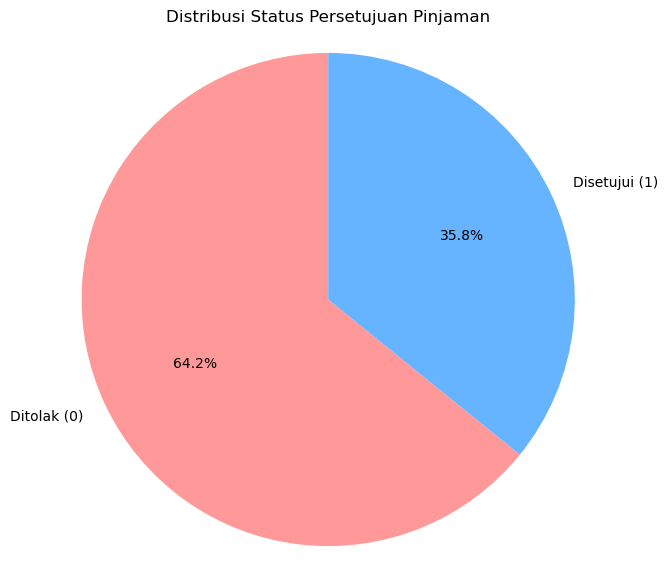

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah setiap kategori dalam 'Loan_Approval_Status'
status_counts = df['Loan_Approval_Status'].value_counts()

# Mengganti label numerik dengan deskripsi yang lebih mudah dipahami
labels = ['Ditolak (0)', 'Disetujui (1)']

print(df["Loan_Approval_Status"].value_counts())

# Membuat pie chart
plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribusi Status Persetujuan Pinjaman')
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
plt.show()

## Membagi variabel prediktor dan target

In [5]:
# Memisahkan prediktor dan target
X = df.drop(columns=["Loan_Approval_Status"])
y = df["Loan_Approval_Status"]

In [6]:
# Melihat predikor
X

,Gender,Age,Education,Loan_Amount_Requested,Bank_Account_History
0,Female,25,Graduate,24535,8
1,Male,36,High School,8288,9
2,Male,43,Postgraduate,10308,7
3,Female,28,High School,33937,9
4,Female,32,Graduate,23360,1
...,...,...,...,...,...
51995,Female,47,High School,15723,2
51996,Male,25,High School,21209,8
51997,Female,48,High School,10540,8
51998,Female,48,High School,16765,3


In [7]:
# Melihat target
y

0        1
1        0
2        0
3        1
4        1
        ..
51995    1
51996    1
51997    0
51998    0
51999    1
Name: Loan_Approval_Status, Length: 52000, dtype: int64

## Train test split

In [8]:
# Import libary untuk splitting
from sklearn.model_selection import train_test_split

# Melakukan splitting pada data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

# Melihat dimensi setiap data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39000, 5)
(13000, 5)
(39000,)
(13000,)


In [9]:
# Import library untuk preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Membuat OOP Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ["Gender", "Education"]),
        ('num', MinMaxScaler(), ["Age", "Loan_Amount_Requested", "Bank_Account_History"])
    ],
    remainder ='passthrough'
)

# Mengaplikasikan preprocessing pada X_train dan X_test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## **SMOTE hanya boleh dilakukan pada data training**

In [10]:
# Import library SMOTE
from imblearn.over_sampling import SMOTE

# Membuat OOP SMOTE
OS = SMOTE(random_state=42)

# Mengaplikasikan SMOTE pada dataset
X_train, y_train = OS.fit_resample(X_train, y_train)

# Melihat dimensi data setleah di SMOTE
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50048, 8)
(13000, 8)
(50048,)
(13000,)


In [11]:
# Mengubah target variabel dari numpy menjadi pandas dataframe
target = pd.DataFrame(y_train)

# Melihat keseimbangan data
target["Loan_Approval_Status"].value_counts()

Loan_Approval_Status
1    25024
0    25024
Name: count, dtype: int64

# Bangun dan Prediksi Model _logistic Regression_

In [12]:
# Import library Logistic Regression dan evaluation Metric
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Membuat OOP untuk Logistic regression
lr = LogisticRegression()

# Fit Logistic regression untuk mendapatkan beta (paramter)
lr.fit(X_train, y_train)

# Memprediksi X_test
y_pred = lr.predict(X_test)

# Menghitung akurasi mdoel
print(f"Akurasi Logstic Regression : {accuracy_score(y_test, y_pred)}")


Akurasi Logstic Regression : 0.79


# Pengenalan berbagai macam model _Machine Learning_ klasifikasi

In [ ]:
# import Model lain untuk klasifikasi
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Declare OOP setiap model
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
svc = SVC()
knn = KNeighborsClassifier()
mlp = MLPClassifier()

# Fit all model
dt.fit(X_train, y_train)
print("fit dt selesai")

rf.fit(X_train, y_train)
print("fit rf selesai")

# svc.fit(X_train, y_train)
# print("fit svc selesai")

knn.fit(X_train, y_train)
print("fit knn selesai")

mlp.fit(X_train, y_train)
print("fit mlp selesai")

# Predict ALl model
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
# y_pred_svc = svc.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

# Hitung semua akurasi model
print("\n") # ini untuk memberi enter

print(f"Akurasi Decision Tree : {accuracy_score(y_test, y_pred_dt)}")
print(f"Akurasi Random Forest : {accuracy_score(y_test, y_pred_rf)}")
# print(f"Akurasi Support Vector Classifier (SVC) : {accuracy_score(y_test, y_pred_svc)}")
print(f"Akurasi K-nearest neighbors : {accuracy_score(y_test, y_pred_knn)}")
print(f"Akurasi Multi Layer Perceptron : {accuracy_score(y_test, y_pred_mlp)}")

fit dt selesai
fit rf selesai
fit knn selesai
fit mlp selesai


Akurasi Decision Tree : 0.7153846153846154
Akurasi Random Forest : 0.7861538461538462
Akurasi K-nearest neighbors : 0.768
Akurasi Multi Layer Perceptron : 0.839


##### Dalam kasus ini dapat disimpulkan bahwa model terbaik adalah Multi layer perceptron